In [1]:
import numpy as np

# Random seed
random_seed = 1354
np.random.seed(random_seed)

# GP configuration
n_bases = 4
n_order = 2
num_points_train = 36
num_points_test = 5000
lower_bounds = [-5] * n_bases
upper_bounds = [5] * n_bases
n_clusters = 3
kernel = "SE"
kernel_type = "isotropic"
normalize = True
n_restart_optimizer = 15
swarm_size = 250

In [2]:
import pyoti.sparse as oti

def styblinski_tang_function(X, alg=oti):
    x1, x2, x3, x4 = X[:,0], X[:,1], X[:,2], X[:,3]
    return 0.5 * (x1**4 - 16*x1**2 + 5*x1 +
                  x2**4 - 16*x2**2 + 5*x2 +
                  x3**4 - 16*x3**2 + 5*x3 +
                  x4**4 - 16*x4**2 + 5*x4)

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [3]:
from scipy.stats import qmc
import jetgp.utils as utils

def generate_sobol_points(num_points):
    sampler = qmc.Sobol(d=n_bases, scramble=True)
    samples = sampler.random_base2(m=int(np.ceil(np.log2(num_points))))
    quasi_samples = samples[:num_points]
    return utils.scale_samples(quasi_samples, lower_bounds, upper_bounds)

X_train = generate_sobol_points(num_points_train)
print("Training points shape:", X_train.shape)

Training points shape: (36, 4)


In [4]:
from sklearn.cluster import KMeans

def cluster_to_submodel_indices(X_train, n_clusters, n_order, n_bases):
    """
    Cluster training points and create proper submodel_indices structure.

    No reordering needed - indices can be non-contiguous!

    Returns:
        submodel_indices: Structure for WDEGP where
            submodel_indices[submodel_idx][deriv_idx] = [list of point indices]
        cluster_indices: Raw indices for each cluster (for reference)
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init='auto')
    labels = kmeans.fit_predict(X_train)

    # Group original indices by cluster (no reordering!)
    cluster_indices = [[] for _ in range(n_clusters)]
    for i, label in enumerate(labels):
        cluster_indices[label].append(i)

    # Build submodel_indices with proper structure:
    # submodel_indices[submodel_idx][deriv_idx] = [indices for that derivative]
    # For 4D with main derivatives: 4 × 2 = 8 derivatives per submodel
    num_derivatives = n_bases * n_order
    submodel_indices = [
        [indices for _ in range(num_derivatives)]
        for indices in cluster_indices
    ]

    return submodel_indices, cluster_indices

submodel_indices, cluster_indices = cluster_to_submodel_indices(
    X_train, n_clusters, n_order, n_bases
)

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Points per cluster: {[len(c) for c in cluster_indices]}")
print(f"Derivatives per submodel: {n_bases * n_order}")
print(f"\nsubmodel_indices structure (one entry per derivative):")
for i, sm_idx in enumerate(submodel_indices):
    print(f"  Submodel {i}: {len(sm_idx)} derivatives, point indices = {sm_idx[0]}")

Number of submodels: 3
Points per cluster: [13, 12, 11]
Derivatives per submodel: 8

submodel_indices structure (one entry per derivative):
  Submodel 0: 8 derivatives, point indices = [1, 3, 4, 8, 12, 15, 19, 21, 24, 29, 31, 32, 34]
  Submodel 1: 8 derivatives, point indices = [2, 5, 6, 9, 10, 14, 16, 17, 18, 22, 26, 30]
  Submodel 2: 8 derivatives, point indices = [0, 7, 11, 13, 20, 23, 25, 27, 28, 33, 35]


In [5]:
import pyoti.sparse as oti
import jetgp.utils as utils

def prepare_submodel_data(X_train, submodel_indices, cluster_indices):
    """
    Prepare derivative data for WDEGP with main derivatives only.

    derivative_specs structure:
        derivative_specs[submodel_idx][deriv_idx] = derivative spec

    For 4D with main derivatives (8 total = 4 dims × 2 orders):
        [0]: [[[1,1]]]  -> df/dx1
        [1]: [[[2,1]]]  -> df/dx2
        [2]: [[[3,1]]]  -> df/dx3
        [3]: [[[4,1]]]  -> df/dx4
        [4]: [[[1,2]]]  -> d2f/dx1^2
        [5]: [[[2,2]]]  -> d2f/dx2^2
        [6]: [[[3,2]]]  -> d2f/dx3^2
        [7]: [[[4,2]]]  -> d2f/dx4^2
    """
    # Build derivative specifications for main derivatives
    # Structure: one spec per derivative (n_bases × n_order total)
    main_derivatives = []
    for order in range(n_order):
        ders = []
        for dim in range(n_bases):
            ders.append([[dim+1, order+1]])
        main_derivatives.append(ders)

    # Each submodel uses the same derivative types
    derivative_specs = [main_derivatives for _ in submodel_indices]


    # Compute function values at ALL training points (shared by all submodels)
    y_function_values = styblinski_tang_function(X_train, alg=np).reshape(-1, 1)

    print(f"Function values shape: {y_function_values.shape}")
    print(f"\nDerivative specs structure:")
    print(f"  Total derivatives per submodel: {len(main_derivatives)}")
    for i, spec in enumerate(main_derivatives):
        order = i // n_bases + 1
        dim = i % n_bases + 1
        print(f"    [{i}] Order {order}, dim {dim}: {spec}")

    # Prepare data for each submodel
    submodel_data = []

    for k, indices in enumerate(cluster_indices):
        # Create OTI array for automatic differentiation
        X_sub_oti = oti.array(X_train[indices])

        # Add dual components for each dimension
        for i in range(n_bases):
            for j in range(X_sub_oti.shape[0]):
                X_sub_oti[j, i] += oti.e(i+1, order=n_order)

        # Evaluate function with OTI to get derivatives
        y_with_derivatives = oti.array([
            styblinski_tang_function(x, alg=oti)[0]
            for x in X_sub_oti
        ])

        # Build submodel data: [func_values, deriv_0, deriv_1, ...]
        current_data = [y_function_values]

        for deriv_spec in derivative_specs[k]:
            for spec in deriv_spec:
                deriv_values = y_with_derivatives.get_deriv(spec).reshape(-1, 1)
                current_data.append(deriv_values)

        submodel_data.append(current_data)

        if k == 0:
            print(f"\nSubmodel 0 data structure:")
            print(f"  Total arrays: {len(current_data)} (1 func + {len(main_derivatives)} derivs)")
            print(f"    [0] Function values: shape {current_data[0].shape}")
            for idx, arr in enumerate(current_data[1:]):
                order = idx // n_bases + 1
                dim = idx % n_bases + 1
                print(f"    [{idx+1}] Order {order}, dim {dim}: shape {arr.shape}")

    return submodel_data, derivative_specs

submodel_data, derivative_specs = prepare_submodel_data(
    X_train, submodel_indices, cluster_indices
)
print(f"\nNumber of submodels: {len(submodel_data)}")

Function values shape: (36, 1)

Derivative specs structure:
  Total derivatives per submodel: 2
    [0] Order 1, dim 1: [[[1, 1]], [[2, 1]], [[3, 1]], [[4, 1]]]
    [1] Order 1, dim 2: [[[1, 2]], [[2, 2]], [[3, 2]], [[4, 2]]]

Submodel 0 data structure:
  Total arrays: 9 (1 func + 2 derivs)
    [0] Function values: shape (36, 1)
    [1] Order 1, dim 1: shape (13, 1)
    [2] Order 1, dim 2: shape (13, 1)
    [3] Order 1, dim 3: shape (13, 1)
    [4] Order 1, dim 4: shape (13, 1)
    [5] Order 2, dim 1: shape (13, 1)
    [6] Order 2, dim 2: shape (13, 1)
    [7] Order 2, dim 3: shape (13, 1)
    [8] Order 2, dim 4: shape (13, 1)

Number of submodels: 3


In [6]:
from jetgp.wdegp.wdegp import wdegp

print("Building WDEGP model...")
print(f"  Training points: {X_train.shape[0]}")
print(f"  Submodels: {len(submodel_indices)}")
print(f"  Derivatives per submodel: {n_bases * n_order} (main only)")

gp_model = wdegp(
    X_train, submodel_data, n_order, n_bases,
     derivative_specs, derivative_locations = submodel_indices, normalize=normalize,
    kernel=kernel, kernel_type=kernel_type
)

print("\nOptimizing hyperparameters...")
params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size=100,
    n_generations=15,
    local_opt_every=None,
    debug=True
)
print("\nGP model built and optimized.")

Building WDEGP model...
  Training points: 36
  Submodels: 3
  Derivatives per submodel: 8 (main only)

Optimizing hyperparameters...


Gen 1: best f=647.1313424977498


Gen 2: best f=647.1313424977498


Gen 3: best f=647.1313424977498


Gen 4: best f=641.6812676844438


...

Gen 11: best f=608.8074605691363


Gen 12: best f=608.8074605691363


Gen 13: best f=608.8074605691363


Gen 14: best f=608.8074605691363


Gen 15: best f=608.8074605691363

GP model built and optimized.


In [7]:
# Generate test points
X_test = generate_sobol_points(num_points_test)

# Predict
y_pred = gp_model.predict(X_test, params, calc_cov=False)
y_true = styblinski_tang_function(X_test, alg=np)

# Compute error metrics
rmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2))
nrmse = rmse / (y_true.max() - y_true.min())
mae = np.mean(np.abs(y_true - y_pred.flatten()))

print(f"Test set size: {num_points_test}")
print(f"RMSE: {rmse:.6f}")
print(f"NRMSE: {nrmse:.6f}")
print(f"MAE: {mae:.6f}")

Test set size: 5000
RMSE: 21.385014
NRMSE: 0.052212
MAE: 8.921197


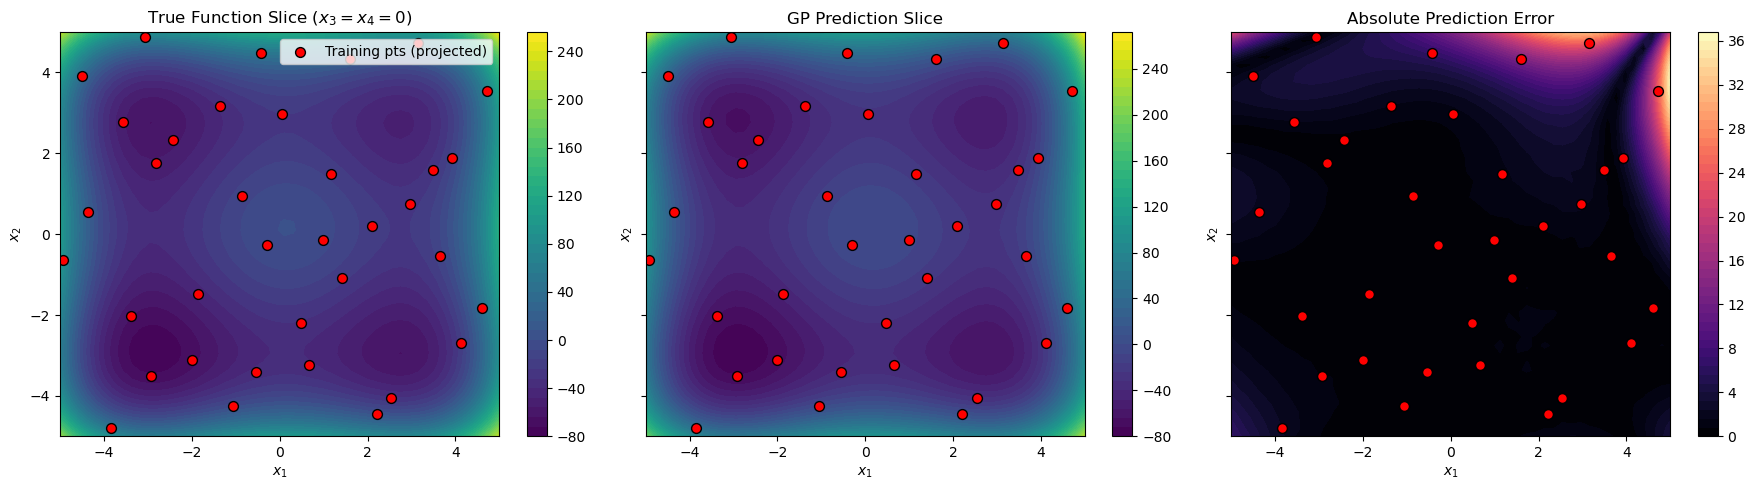

In [8]:
import matplotlib.pyplot as plt

# Evaluate on 2D slice (x3=0, x4=0)
grid_points = 50
x1x2_lin = np.linspace(lower_bounds[0], upper_bounds[0], grid_points)
X1_grid, X2_grid = np.meshgrid(x1x2_lin, x1x2_lin)
X_slice = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
X_slice = np.hstack([X_slice, np.zeros((X_slice.shape[0], 2))])  # x3=0, x4=0

y_slice_pred = gp_model.predict(X_slice, params, calc_cov=False)
y_slice_true = styblinski_tang_function(X_slice, alg=np)

# Contour plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Project training points to 2D (showing x1, x2 coordinates)
X_train_proj = X_train[:, :2]

# True function
c1 = axes[0].contourf(X1_grid, X2_grid, y_slice_true.reshape(X1_grid.shape),
                      levels=50, cmap="viridis")
fig.colorbar(c1, ax=axes[0])
axes[0].set_title("True Function Slice ($x_3=x_4=0$)")
axes[0].scatter(X_train_proj[:, 0], X_train_proj[:, 1],
                c="red", edgecolor="k", s=50, label="Training pts (projected)")

# GP prediction
c2 = axes[1].contourf(X1_grid, X2_grid, y_slice_pred.reshape(X1_grid.shape),
                      levels=50, cmap="viridis")
fig.colorbar(c2, ax=axes[1])
axes[1].set_title("GP Prediction Slice")
axes[1].scatter(X_train_proj[:, 0], X_train_proj[:, 1],
                c="red", edgecolor="k", s=50)

# Absolute error
error_grid = np.abs(y_slice_true - y_slice_pred.flatten())
c3 = axes[2].contourf(X1_grid, X2_grid, error_grid.reshape(X1_grid.shape),
                      levels=50, cmap="magma")
fig.colorbar(c3, ax=axes[2])
axes[2].set_title("Absolute Prediction Error")
axes[2].scatter(X_train_proj[:, 0], X_train_proj[:, 1],
                c="red", edgecolor="k", s=50)

for ax in axes:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

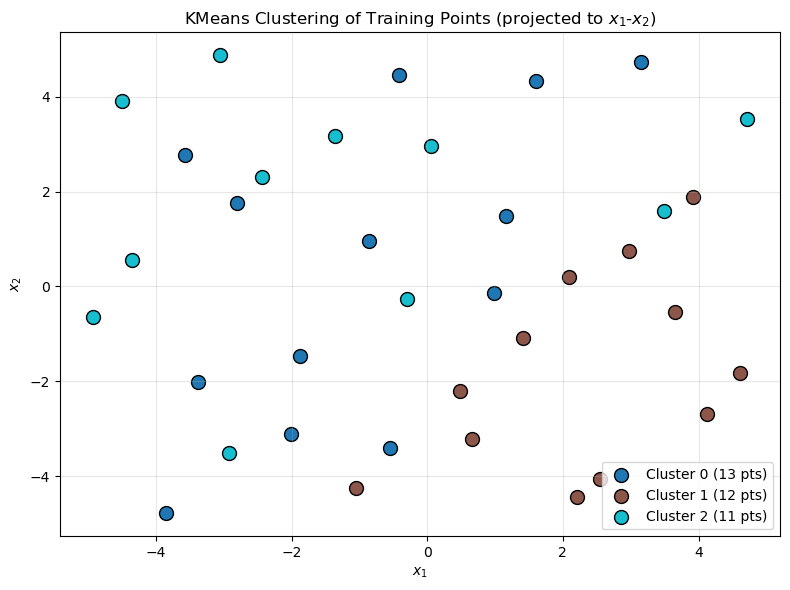

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for k, indices in enumerate(cluster_indices):
    X_cluster = X_train[indices, :2]
    ax.scatter(X_cluster[:, 0], X_cluster[:, 1],
               c=[colors[k]], s=100, edgecolor='k',
               label=f'Cluster {k} ({len(indices)} pts)')

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("KMeans Clustering of Training Points (projected to $x_1$-$x_2$)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()